In [16]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
from sklearn.metrics import precision_recall_curve


In [17]:
df = pd.read_csv("../data/predicted/train_predicted_xgboost_ONLINE_regularization_subset_added_velocity_features_removed_online_added_mcc_risk_score_velocity_errors.csv", parse_dates=["date"])


In [18]:
mapping = {True:"Yes", False:"No"}
df["predicted_class"] = df["predicted_prob"]>0.5
df["predicted_class"] = df["predicted_class"].map(mapping)

In [19]:
incorrect_classified = df[df["target"]!=df["predicted_class"]]
correct_classified = df[df["target"]==df["predicted_class"]]
print("Incorrect:", incorrect_classified.shape[0])
print("Correct:", correct_classified.shape[0])

Incorrect: 105339
Correct: 731711


In [20]:
incorrect_with_high_probability_fp = incorrect_classified[incorrect_classified["predicted_prob"]>0.5]
incorrect_with_high_probability_fn = incorrect_classified[incorrect_classified["predicted_prob"]<0.1]
correct_classified_tn = correct_classified[correct_classified["predicted_prob"]<0.5]
correct_classified_tp = correct_classified[correct_classified["predicted_prob"]>0.5]

print("False negatives", incorrect_with_high_probability_fn.shape[0])
print("False positives", incorrect_with_high_probability_fp.shape[0])

False negatives 292
False positives 102548


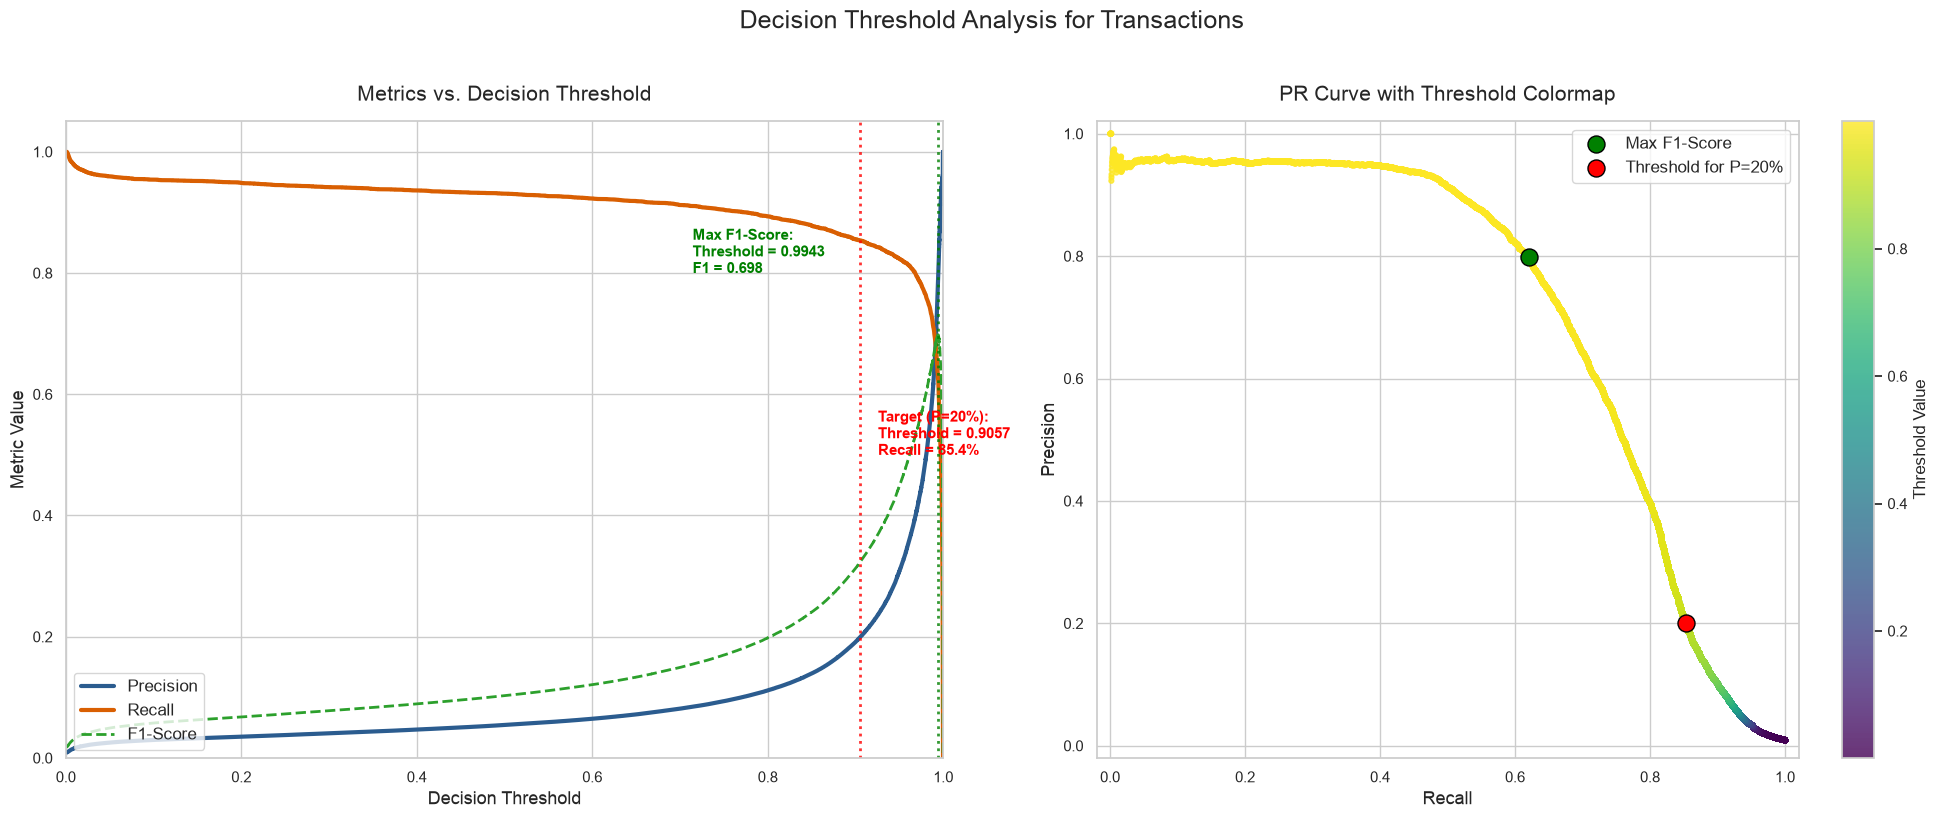

In [21]:


def plot_threshold_analysis(df):
    valid_data = df[['target', 'predicted_prob']].dropna()
    y_true = (valid_data["target"] == "Yes").astype(int)
    y_prob = valid_data["predicted_prob"]
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    p_curve = precisions[:-1]
    r_curve = recalls[:-1]
    f1_curve = f1_scores[:-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.set_theme(style="whitegrid")
    
    ax1 = axes[0]
    ax1.plot(thresholds, p_curve, label="Precision", color="#2b5c8f", lw=3)
    ax1.plot(thresholds, r_curve, label="Recall", color="#d95f02", lw=3)
    ax1.plot(thresholds, f1_curve, label="F1-Score", color="#2ca02c", lw=2, linestyle="--")
    
    best_f1_idx = np.argmax(f1_curve)
    best_thresh_f1 = thresholds[best_f1_idx]
    best_f1_val = f1_curve[best_f1_idx]
    
    target_p = 0.20
    p_target_indices = np.where(p_curve >= target_p)[0]
    if len(p_target_indices) > 0:
        thresh_p_target = thresholds[p_target_indices[0]]
        recall_p_target = r_curve[p_target_indices[0]]
        
        ax1.axvline(x=thresh_p_target, color="red", linestyle=":", alpha=0.8, lw=2)
        ax1.text(thresh_p_target + 0.02, 0.5, f"Target (P={target_p:.0%}):\nThreshold = {thresh_p_target:.4f}\nRecall = {recall_p_target:.1%}", color="red", fontsize=11, weight="bold")
        
    ax1.axvline(x=best_thresh_f1, color="green", linestyle=":", alpha=0.8, lw=2)
    ax1.text(best_thresh_f1 - 0.28, 0.8, f"Max F1-Score:\nThreshold = {best_thresh_f1:.4f}\nF1 = {best_f1_val:.3f}", color="green", fontsize=11, weight="bold")
    
    ax1.set_title("Metrics vs. Decision Threshold", fontsize=15, pad=15)
    ax1.set_xlabel("Decision Threshold", fontsize=13)
    ax1.set_ylabel("Metric Value", fontsize=13)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=12, loc="lower left")
    
    ax2 = axes[1]
    sc = ax2.scatter(r_curve, p_curve, c=thresholds, cmap="viridis", s=12, alpha=0.8)
    
    cbar = plt.colorbar(sc, ax=ax2)
    cbar.set_label("Threshold Value", fontsize=12)
    
    ax2.scatter(recalls[:-1][best_f1_idx], precisions[:-1][best_f1_idx], color="green", s=150, edgecolors="black", zorder=5, label="Max F1-Score")
    if len(p_target_indices) > 0:
        ax2.scatter(recalls[:-1][p_target_indices[0]], precisions[:-1][p_target_indices[0]], color="red", s=150, edgecolors="black", zorder=5, label=f"Threshold for P={target_p:.0%}")
        
    ax2.set_title("PR Curve with Threshold Colormap", fontsize=15, pad=15)
    ax2.set_xlabel("Recall", fontsize=13)
    ax2.set_ylabel("Precision", fontsize=13)
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)
    ax2.legend(fontsize=12, loc="upper right")
    
    plt.suptitle("Decision Threshold Analysis for Transactions", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_threshold_analysis(df)